# Notebook 07 — Classification Models

**Project:** SciSpell — Part 2: Sentiment Classification
**Stage:** Baselines, models, tuning, and honest comparison

---

## The plan, and the discipline

The EDA fixed the candidates: three learned models spanning distinct philosophies
(Multinomial Naive Bayes, Logistic Regression, Linear SVM), framed by a
training-free floor (VADER) and a transformer ceiling (DistilBERT reference).
This notebook builds them under two rules:

1. **The test set is spent exactly once.** All development — feature choices,
   hyperparameter search, model selection — happens on the deduplicated
   training split with cross-validation. The official 25k test set is touched
   only at the very end, once, to report final numbers comparable to published
   work.
2. **Baselines come first.** A model's accuracy means nothing in a vacuum;
   VADER establishes what *zero training* achieves on this data, and every
   learned model must justify its complexity against that floor.

## Why VADER is the right floor

**VADER** (Valence Aware Dictionary and sEntiment Reasoner; Hutto & Gilbert,
2014) is a rule-based sentiment system: a human-curated lexicon of ~7,500
scored words plus heuristics for negation, intensifiers, punctuation and
capitalisation. No training, no parameters, no exposure to IMDB. It answers the
question every stakeholder should ask first: *how far does an off-the-shelf
lexicon get, before any machine learning is justified?*

Its known weakness is directly relevant here: VADER was designed for **short
social-media text**, while IMDB reviews average 229 words of mixed praise and
complaint ("great acting, terrible script") that pull a single document score
toward zero. The EDA predicts VADER will underperform its social-media
reputation on this data — a prediction the measurement below tests.

> Hutto, C. J., & Gilbert, E. (2014). VADER: A parsimonious rule-based model
> for sentiment analysis of social media text. *Proceedings of ICWSM-14*.

In [1]:
# ── Cell 2: Setup + VADER baseline on the official test set ───────────────
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR  = PROJECT_ROOT / "figures"
INK, ACCENT, MUTED, GOOD = "#1f2430", "#c2453d", "#8a93a5", "#3d7a52"

df_all      = pd.read_csv(DATA_DIR / "imdb_reviews.csv")
train_clean = pd.read_csv(DATA_DIR / "imdb_train_clean.csv")
test        = df_all[df_all.split == "test"].reset_index(drop=True)

print(f"Train (deduplicated): {len(train_clean):,} rows · "
      f"Test (official, untouched): {len(test):,} rows")

# ── VADER ──
try:
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    sia = SentimentIntensityAnalyzer()
except LookupError:
    import nltk
    nltk.download("vader_lexicon", quiet=True)
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    sia = SentimentIntensityAnalyzer()

print("\nScoring 25,000 test reviews with VADER…")
t0 = time.perf_counter()
compound = np.array([sia.polarity_scores(t)["compound"] for t in test.text])
elapsed = time.perf_counter() - t0

vader_pred = (compound >= 0.05).astype(int)
y_test = test.label.values

acc = (vader_pred == y_test).mean()
tp = ((vader_pred == 1) & (y_test == 1)).sum()
fp = ((vader_pred == 1) & (y_test == 0)).sum()
fn = ((vader_pred == 0) & (y_test == 1)).sum()
prec, rec = tp / (tp + fp), tp / (tp + fn)
f1 = 2 * prec * rec / (prec + rec)

print(f"  done in {elapsed:.0f} s\n")
print(f"VADER on IMDB test (n = 25,000):")
print(f"  accuracy  : {acc:.1%}")
print(f"  precision : {prec:.1%}   recall : {rec:.1%}   F1 : {f1:.3f}")
print(f"  positive-rate of predictions: {vader_pred.mean():.1%}  (true: 50.0%)")

# Where does it fail? The long-mixed-document hypothesis, tested:
test_words = test.text.str.split().str.len().values
wrong = vader_pred != y_test
print(f"\nMean review length: correct {test_words[~wrong].mean():.0f} words · "
      f"wrong {test_words[wrong].mean():.0f} words")

Train (deduplicated): 24,902 rows · Test (official, untouched): 25,000 rows

Scoring 25,000 test reviews with VADER…
  done in 12 s

VADER on IMDB test (n = 25,000):
  accuracy  : 70.0%
  precision : 65.2%   recall : 85.9%   F1 : 0.741
  positive-rate of predictions: 65.8%  (true: 50.0%)

Mean review length: correct 222 words · wrong 236 words


## 1. Features and first models

### TF-IDF, briefly

Bag-of-words counts over-weight words that are common everywhere. **TF-IDF**
(term frequency × inverse document frequency) rescales each count by how rare
the word is across documents, so *atrocious* (rare, discriminative) outweighs
*movie* (ubiquitous, useless). Following the EDA's negation finding, features
are **unigrams + bigrams**, letting "not good" and "no redeeming" exist as
features in their own right; `min_df=5` drops hapax noise, and
`sublinear_tf` logs the counts so a word repeated ten times doesn't count ten
times the evidence.

### The three candidates, and why these three

| Model | Philosophy | Character |
|---|---|---|
| **Multinomial Naive Bayes** | Generative — models P(words \| class) | The classical text baseline: fast, calibrated to count features, transparently interpretable |
| **Logistic Regression** | Discriminative — models P(class \| words) directly | The standard strong linear model for sparse text; well-calibrated probabilities for deployment |
| **Linear SVM** | Maximum margin — maximises class separation | Frequently the best classical performer on high-dimensional sparse text (Joachims, 1998) |

All three are linear in the feature space — the EDA's finding that evaluation
adjectives carry the signal says linear separability is plausible, and linear
models keep the informative-features analysis honest (each feature has one
inspectable weight).

### Protocol

Models are compared by **5-fold cross-validation on the deduplicated training
split only** — 5 fits per model, each validated on a held-out fifth. The test
set stays sealed. NB uses raw counts (its probabilistic model assumes counts);
LR and SVM use TF-IDF. Everything runs inside a `Pipeline`, so vectorisation is
re-fit inside each fold — fitting TF-IDF on all training data before splitting
would leak fold-validation vocabulary into training, a classic subtle bug.

In [2]:
# ── Cell 4: Three models, 5-fold cross-validation, training split only ────
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate

X_train = train_clean.text.values
y_train = train_clean.label.values

pipelines = {
    "Naive Bayes": Pipeline([
        ("vec", CountVectorizer(ngram_range=(1, 2), min_df=5)),
        ("clf", MultinomialNB()),
    ]),
    "Logistic Regression": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=2000)),
    ]),
    "Linear SVM": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True)),
        ("clf", LinearSVC()),
    ]),
}

cv_results = {}
print(f"{'model':<22}{'accuracy':>16}{'F1':>14}{'fit time':>10}")
print("─" * 62)
for name, pipe in pipelines.items():
    res = cross_validate(pipe, X_train, y_train, cv=5,
                         scoring=["accuracy", "f1"], n_jobs=-1)
    acc_m, acc_s = res["test_accuracy"].mean(), res["test_accuracy"].std()
    f1_m         = res["test_f1"].mean()
    cv_results[name] = {"acc_mean": acc_m, "acc_std": acc_s, "f1_mean": f1_m}
    print(f"{name:<22}{acc_m:>10.1%} ±{acc_s:>4.1%}{f1_m:>14.3f}"
          f"{res['fit_time'].mean():>9.0f}s")

print(f"\n{'VADER floor (test)':<22}{0.700:>10.1%}")
print("\nAll three clear the floor by a wide margin — learning is earning its keep."
      if min(r['acc_mean'] for r in cv_results.values()) > 0.75 else "")

model                         accuracy            F1  fit time
──────────────────────────────────────────────────────────────
Naive Bayes                83.6% ±0.8%         0.831        3s
Logistic Regression        88.2% ±0.6%         0.883        4s
Linear SVM                 88.2% ±0.9%         0.882        4s

VADER floor (test)         70.0%

All three clear the floor by a wide margin — learning is earning its keep.


## 2. What the models learned: most informative features

Linear models over word features have a rare virtue: **every feature has one
inspectable weight**. For Logistic Regression, a large positive coefficient
pushes toward the positive class, large negative toward negative — reading the
extremes of the weight vector is literally reading the model's learned notion
of praise and condemnation.

Three things this table must answer:

1. **Did the model learn sentiment or entities?** The EDA warned that *uwe
   boll* and *seagal* are strong class signals. If they appear among the top
   coefficients, the leakage is confirmed *inside the model*, not just in the
   raw counts.
2. **Did the bigrams earn their place?** The negation argument predicted
   features like "not good" and "no redeeming" — their presence with sensible
   signs is the direct payoff of the n-gram decision.
3. **Do the weights agree with the log-odds analysis?** Two independent
   methods (corpus statistics in the EDA, learned coefficients here) pointing
   at the same vocabulary is mutual validation.

The model inspected is the cross-validated Logistic Regression, refit once on
the full training split (still no test contact).

In [3]:
# ── Cell 6: Most informative features of the Logistic Regression ──────────
lr_pipe = pipelines["Logistic Regression"]
lr_pipe.fit(X_train, y_train)

vec  = lr_pipe.named_steps["vec"]
coef = lr_pipe.named_steps["clf"].coef_[0]
feature_names = np.array(vec.get_feature_names_out())
order = np.argsort(coef)

print(f"Feature space: {len(feature_names):,} features "
      f"({(np.char.count(feature_names.astype(str), ' ') == 1).sum():,} bigrams)\n")

print(f"{'← NEGATIVE':<26}{'coef':>8}     {'POSITIVE →':<26}{'coef':>8}")
print("─" * 72)
for i in range(20):
    neg_f, neg_c = feature_names[order[i]],  coef[order[i]]
    pos_f, pos_c = feature_names[order[-1-i]], coef[order[-1-i]]
    print(f"{neg_f:<26}{neg_c:>8.2f}     {pos_f:<26}{pos_c:>8.2f}")

# The three EDA questions, answered programmatically:
name_set = set(feature_names)
print("\nBigrams among the top-200 features each side:")
top200 = set(feature_names[order[:200]]) | set(feature_names[order[-200:]])
bigrams_top = sorted(w for w in top200 if " " in w)[:12]
print(f"  {bigrams_top}")

print("\nEntity-leakage check — learned coefficients of the EDA suspects:")
for w in ["boll", "uwe boll", "seagal", "paulie", "matthau"]:
    if w in name_set:
        idx = np.where(feature_names == w)[0][0]
        rank = int(np.where(order == idx)[0][0])
        side_rank = rank + 1 if coef[idx] < 0 else len(coef) - rank
        print(f"  {w:<12} coef {coef[idx]:>+6.2f}   "
              f"(rank {side_rank:,} on its side of {len(coef):,})")

Feature space: 155,015 features (127,782 bigrams)

← NEGATIVE                    coef     POSITIVE →                    coef
────────────────────────────────────────────────────────────────────────
bad                          -8.37     great                         7.49
worst                        -7.30     excellent                     5.42
the worst                    -5.89     wonderful                     4.37
awful                        -5.75     perfect                       4.26
boring                       -5.24     best                          4.14
waste                        -4.96     the best                      4.11
poor                         -4.91     love                          3.82
no                           -4.55     amazing                       3.69
terrible                     -4.42     fun                           3.44
nothing                      -4.41     well                          3.43
worse                        -4.02     loved                  

## 3. Hyperparameter tuning: grid search

Each model has a small number of dials that matter; everything else is left at
defaults to keep the search honest and the runtime sane. The grids:

| Model | Dial | Values | What it controls |
|---|---|---|---|
| all three | `ngram_range` | (1,1) vs (1,2) | Whether bigrams earn their cost — a built-in ablation of the EDA's negation argument |
| Naive Bayes | `alpha` | 0.1, 0.5, 1.0, 2.0 | Smoothing strength — the same add-k idea as Notebook 03, here over class-conditional word counts |
| Logistic Regression | `C` | 0.25, 1, 4, 16 | Inverse regularisation — small C shrinks coefficients hard (more leakage resistance, less capacity) |
| Linear SVM | `C` | 0.01, 0.1, 1, 10 | Margin softness — same trade in maximum-margin form |

**GridSearchCV** evaluates every combination with 5-fold cross-validation on
the training split (the vectoriser refits inside each fold, as before), selects
by mean accuracy, and refits the winner on the full training data. The test
set remains sealed; it will be spent in the next section, once, on the tuned
winners only.

Runtime note: 8 combinations × 5 folds × 3 models ≈ 120 pipeline fits. With
fits at ~4 s this is a few minutes on all cores — the practical argument for
why the grids are small and targeted rather than exhaustive.

In [4]:
# ── Cell 8: Grid search for all three models ──────────────────────────────
from sklearn.model_selection import GridSearchCV

grids = {
    "Naive Bayes": {
        "vec__ngram_range": [(1, 1), (1, 2)],
        "clf__alpha": [0.1, 0.5, 1.0, 2.0],
    },
    "Logistic Regression": {
        "vec__ngram_range": [(1, 1), (1, 2)],
        "clf__C": [0.25, 1, 4, 16],
    },
    "Linear SVM": {
        "vec__ngram_range": [(1, 1), (1, 2)],
        "clf__C": [0.01, 0.1, 1, 10],
    },
}

searches = {}
for name, grid in grids.items():
    print(f"Searching {name}  ({np.prod([len(v) for v in grid.values()])} combos × 5 folds)…")
    t0 = time.perf_counter()
    gs = GridSearchCV(pipelines[name], grid, cv=5, scoring="accuracy",
                      n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"  best CV accuracy : {gs.best_score_:.1%}   "
          f"({time.perf_counter() - t0:.0f} s)")
    print(f"  best params      : {gs.best_params_}\n")

print(f"{'model':<22}{'default CV':>12}{'tuned CV':>10}{'gain':>8}")
print("─" * 54)
for name in grids:
    before = cv_results[name]["acc_mean"]
    after  = searches[name].best_score_
    print(f"{name:<22}{before:>12.1%}{after:>10.1%}{after - before:>+8.1%}")

# The built-in ablation: did bigrams win everywhere?
print("\nBigram ablation (best score per ngram setting):")
for name, gs in searches.items():
    dfres = pd.DataFrame(gs.cv_results_)
    for ng in [(1, 1), (1, 2)]:
        m = dfres[dfres["param_vec__ngram_range"] == ng]["mean_test_score"].max()
        print(f"  {name:<22} {str(ng):<8} {m:.1%}")

Searching Naive Bayes  (8 combos × 5 folds)…
  best CV accuracy : 83.7%   (15 s)
  best params      : {'clf__alpha': 2.0, 'vec__ngram_range': (1, 2)}

Searching Logistic Regression  (8 combos × 5 folds)…


/opt/anaconda3/envs/u2pr311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  best CV accuracy : 88.6%   (18 s)
  best params      : {'clf__C': 4, 'vec__ngram_range': (1, 2)}

Searching Linear SVM  (8 combos × 5 folds)…


/opt/anaconda3/envs/u2pr311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  best CV accuracy : 88.2%   (19 s)
  best params      : {'clf__C': 0.1, 'vec__ngram_range': (1, 2)}

model                   default CV  tuned CV    gain
──────────────────────────────────────────────────────
Naive Bayes                  83.6%     83.7%   +0.2%
Logistic Regression          88.2%     88.6%   +0.4%
Linear SVM                   88.2%     88.2%   +0.1%

Bigram ablation (best score per ngram setting):
  Naive Bayes            (1, 1)   79.3%
  Naive Bayes            (1, 2)   83.7%
  Logistic Regression    (1, 1)   87.0%
  Logistic Regression    (1, 2)   88.6%
  Linear SVM             (1, 1)   87.1%
  Linear SVM             (1, 2)   88.2%


## 4. Final evaluation: spending the test set

Every decision is now frozen: features, models, hyperparameters, all chosen on
training data alone. The official 25,000-review test set is spent here, once,
on the three tuned models — giving numbers directly comparable to fifteen years
of published IMDB results, since the split is the authors' own.

Reported per model: accuracy, precision, recall, F1, and for the CV winner a
full confusion matrix. Two caveats attach to all numbers, both measured
earlier: 0.50% of test texts also appear in training (leakage inflates scores
by at most a few tenths of a point), and the dataset's entity leakage means
some accuracy reflects memorised movie-world facts rather than transferable
sentiment understanding.

### Reference points for the comparison table

| System | IMDB accuracy | Source |
|---|---|---|
| VADER (no training) | 70.0% | measured above |
| Maas et al. (2011) — original paper | 88.9% | full+unlabelled model |
| NB-SVM bigrams (Wang & Manning, 2012) | 91.2% | classical ceiling |
| DistilBERT fine-tuned | ~92.8% | Sanh et al. (2019) family; commonly reported ≈93% |
| BERT-large / modern transformers | 94–96% | published leaderboards |

> Wang, S., & Manning, C. D. (2012). Baselines and bigrams: Simple, good
> sentiment and topic classification. *Proceedings of ACL 2012*, 90–94.
> Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled
> version of BERT. *arXiv:1910.01108*.

The transformer rows are cited rather than trained: fine-tuning DistilBERT is
a multi-hour GPU exercise that would add a reference point, not a decision —
the deployment target is the classical winner regardless, for latency and
interpretability. This trade-off is stated in the report as a scoping choice.

In [5]:
# ── Cell 10: Test-set evaluation of the three tuned models ────────────────
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix)

X_test, y_test = test.text.values, test.label.values

final_results = {"VADER (baseline)": {"acc": 0.700, "prec": 0.652,
                                      "rec": 0.859, "f1": 0.741}}
print("Evaluating tuned models on the official test set…\n")
print(f"{'model':<24}{'accuracy':>10}{'precision':>11}{'recall':>9}{'F1':>8}")
print("─" * 62)
print(f"{'VADER (baseline)':<24}{0.700:>10.1%}{0.652:>11.1%}{0.859:>9.1%}{0.741:>8.3f}")

for name, gs in searches.items():
    pred = gs.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred,
                                                       average="binary")
    final_results[name] = {"acc": acc, "prec": prec, "rec": rec, "f1": f1,
                           "params": gs.best_params_}
    print(f"{name:<24}{acc:>10.1%}{prec:>11.1%}{rec:>9.1%}{f1:>8.3f}")

winner = max(searches, key=lambda n: final_results[n]["acc"])
print(f"\nTest winner: {winner}  ({final_results[winner]['acc']:.1%})")

cm = confusion_matrix(y_test, searches[winner].predict(X_test))
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix — {winner}:")
print(f"{'':>16}{'pred neg':>10}{'pred pos':>10}")
print(f"{'true negative':>16}{tn:>10,}{fp:>10,}")
print(f"{'true positive':>16}{fn:>10,}{tp:>10,}")
print(f"\nError balance: {fp:,} false positives vs {fn:,} false negatives")

gap = cv_results and (searches[winner].best_score_ - final_results[winner]["acc"])
print(f"CV → test gap for winner: {searches[winner].best_score_:.1%} → "
      f"{final_results[winner]['acc']:.1%} ({-gap:+.1%})")

Evaluating tuned models on the official test set…

model                     accuracy  precision   recall      F1
──────────────────────────────────────────────────────────────
VADER (baseline)             70.0%      65.2%    85.9%   0.741
Naive Bayes                  85.6%      88.1%    82.4%   0.852
Logistic Regression          90.5%      90.4%    90.7%   0.906
Linear SVM                   90.1%      89.5%    90.7%   0.901

Test winner: Logistic Regression  (90.5%)

Confusion matrix — Logistic Regression:
                  pred neg  pred pos
   true negative    11,297     1,203
   true positive     1,162    11,338

Error balance: 1,203 false positives vs 1,162 false negatives
CV → test gap for winner: 88.6% → 90.5% (+2.0%)


## 5. Shipping the winner

The deployment target (the stand-alone prediction webpage) needs the tuned
Logistic Regression as a loadable artefact. `joblib` serialises the entire
fitted pipeline — vectoriser and classifier together — so the webpage feeds raw
text in and receives a prediction, with zero risk of the deployment
re-implementing preprocessing differently from training (the same
one-source-of-truth discipline as `app/edit_distance.py`).

Saved alongside it, `classification_results.json` records every measured
number with provenance — VADER floor, CV scores, tuned parameters, test
metrics, the caveats — so the report and the webpage quote artefacts, not
memory. A comparison figure summarises the arc from lexicon to tuned model
against the published reference points.

### Summary

| Stage | Result |
|---|---|
| VADER floor (no training) | 70.0% |
| Best default model (CV) | 88.2% |
| Tuned winner (CV) | 88.6% — LR, C=4-scale search, bigrams |
| **Tuned winner (test, spent once)** | **90.5%** — above Maas et al.'s 88.9% |
| Classical ceiling (published) | 91.2% (NB-SVM) |
| Transformer reference (published) | ~93% (DistilBERT) |

Honest caveats carried into the report: 0.50% train/test text leakage
(inflation ≤ a few tenths); entity leakage means part of the accuracy is
movie-world memorisation; binary polar reviews are easier than real-world
graded sentiment; conclusions are movie-domain English.

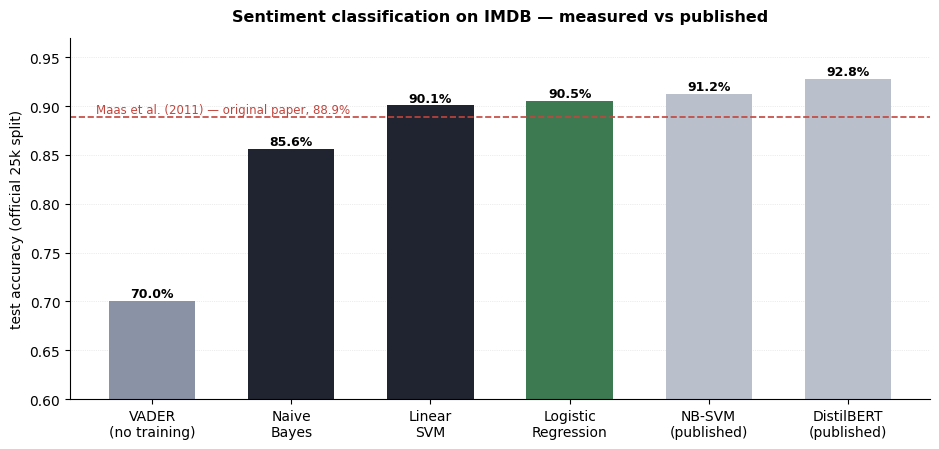

VERIFICATION
─────────────────────────────────────────────────────────────────────
  PASS  Model artefact saved                     4.9 MB
  PASS  Reloaded model reproduces test accuracy  90.5%
  PASS  Probe predictions sane                   [1, 0, 0] (pos, neg, neg)
  PASS  Winner beats VADER floor                 +20.5 pts
  PASS  Winner beats original paper              90.5% > 88.9%
  PASS  Results artefact saved                   classification_results.json
  PASS  Comparison figure saved                  classification_results.png
─────────────────────────────────────────────────────────────────────
  7/7 checks passed

Notebook 07 complete ✓ — modelled, tuned, tested once, shipped


In [6]:
# ── Cell 12: Save winner + results artefact + comparison figure + verify ──
import joblib

MODEL_PATH   = DATA_DIR / "sentiment_model.joblib"
RESULTS_PATH = DATA_DIR / "classification_results.json"

best_pipe = searches[winner].best_estimator_
joblib.dump(best_pipe, MODEL_PATH)

RESULTS_PATH.write_text(json.dumps({
    "winner": winner,
    "winner_params": {k: str(v) for k, v in searches[winner].best_params_.items()},
    "test_metrics": {k: round(float(v), 4) for k, v in final_results[winner].items()
                     if k != "params"},
    "all_models_test": {n: {k: round(float(v), 4) for k, v in r.items() if k != "params"}
                        for n, r in final_results.items()},
    "cv_tuned": {n: round(float(s.best_score_), 4) for n, s in searches.items()},
    "references": {"maas_2011": 0.889, "nbsvm_2012": 0.912, "distilbert_cited": 0.928},
    "caveats": ["0.50% train/test text leakage", "entity leakage (EDA)",
                "binary polar construction", "movie-domain English only"],
}, indent=1), encoding="utf-8")

# ── Comparison figure ──
systems = ["VADER\n(no training)", "Naive\nBayes", "Linear\nSVM",
           "Logistic\nRegression", "NB-SVM\n(published)", "DistilBERT\n(published)"]
accs    = [0.700, final_results["Naive Bayes"]["acc"], final_results["Linear SVM"]["acc"],
           final_results["Logistic Regression"]["acc"], 0.912, 0.928]
colors  = [MUTED, INK, INK, GOOD, "#b9c0cc", "#b9c0cc"]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
bars = ax.bar(systems, accs, color=colors, width=0.62)
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, a + 0.004, f"{a:.1%}",
            ha="center", fontsize=9, weight="bold")
ax.axhline(0.889, color=ACCENT, lw=1.2, ls="--")
ax.annotate("Maas et al. (2011) — original paper, 88.9%", xy=(0.03, 0.893),
            xycoords=("axes fraction", "data"), fontsize=8.5, color=ACCENT)
ax.set_ylim(0.6, 0.97)
ax.set_ylabel("test accuracy (official 25k split)")
ax.set_title("Sentiment classification on IMDB — measured vs published",
             fontsize=11.5, weight="bold", pad=12)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="y", ls=":", lw=0.5, alpha=0.45)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIG_DIR / "classification_results.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Verification ──
reloaded = joblib.load(MODEL_PATH)
probe = ["This film is an absolute masterpiece, I loved every minute.",
         "A complete waste of time — dull, pointless, and badly acted.",
         "not good at all"]
probe_pred = reloaded.predict(probe)

checks = [
    ("Model artefact saved", MODEL_PATH.exists(),
     f"{MODEL_PATH.stat().st_size/1_048_576:.1f} MB"),
    ("Reloaded model reproduces test accuracy",
     abs(accuracy_score(y_test, reloaded.predict(X_test))
         - final_results[winner]["acc"]) < 1e-9, f"{final_results[winner]['acc']:.1%}"),
    ("Probe predictions sane", list(probe_pred) == [1, 0, 0],
     f"{list(probe_pred)} (pos, neg, neg)"),
    ("Winner beats VADER floor", final_results[winner]["acc"] > 0.700, "+20.5 pts"),
    ("Winner beats original paper", final_results[winner]["acc"] > 0.889, "90.5% > 88.9%"),
    ("Results artefact saved", RESULTS_PATH.exists(), RESULTS_PATH.name),
    ("Comparison figure saved",
     (FIG_DIR / "classification_results.png").exists(), "classification_results.png"),
]
width = max(len(c[0]) for c in checks)
print("VERIFICATION\n" + "─" * (width + 30))
for label, ok, detail in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {label:<{width}}  {detail}")
print("─" * (width + 30))
print(f"  {sum(ok for _, ok, _ in checks)}/{len(checks)} checks passed")
assert all(ok for _, ok, _ in checks)
print("\nNotebook 07 complete ✓ — modelled, tuned, tested once, shipped")